# ⚡ Building Energy Consumption Forecasting Using ML

**Goal:** Predict building energy consumption using historical data, weather, metadata, and holiday signals.  
**Models:** Linear Regression · Random Forest · XGBoost

## 01. Project Overview



Energy consumption forecasting is critical for smart building management,
energy optimization, and sustainability planning.

The objective of this project is to develop machine learning models that
can accurately predict building energy consumption using:

- Weather conditions
- Building metadata
- Time-based features
- Historical energy consumption

The final model will be deployed using Streamlit for interactive predictions.

## 02 · Environment Setup

In [1]:
# Importing required libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split

from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor

from xgboost import XGBRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

import warnings
warnings.filterwarnings("ignore")

## 03 · Data Loading

In [2]:
# Loading datasets for Building Energy Consumption Analysis & Prediction

# Main training dataset
train = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-training-data.csv',
    sep=';'
)
# Weather dataset
weather = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-weather.csv',
    sep=';'
)

# Metadata dataset
metadata = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-metadata.csv',
    sep=';'
)

# Holidays dataset
holidays = pd.read_csv(
    '/content/power-laws-forecasting-energy-consumption-holidays.csv',
    sep=';'
)
for name, df in [("train", train), ("weather", weather),
                 ("metadata", metadata), ("holidays", holidays)]:
    print(f"{name:>10}: {df.shape[0]:>8,} rows × {df.shape[1]} cols")

     train:  458,575 rows × 5 cols
   weather:  435,649 rows × 4 cols
  metadata:      267 rows × 11 cols
  holidays:    8,387 rows × 3 cols


### Preview

In [3]:
# Checking the shape (rows, columns) of all dataset

print(train.shape)
print(weather.shape)
print(metadata.shape)
print(holidays.shape)

# Checking structure and data types of all datasets

train.info()
weather.info()
metadata.info()
holidays.info()

(458575, 5)
(435649, 4)
(267, 11)
(8387, 3)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 458575 entries, 0 to 458574
Data columns (total 5 columns):
 #   Column      Non-Null Count   Dtype  
---  ------      --------------   -----  
 0   obs_id      458575 non-null  int64  
 1   SiteId      458575 non-null  int64  
 2   Timestamp   458575 non-null  object 
 3   ForecastId  458574 non-null  float64
 4   Value       452200 non-null  float64
dtypes: float64(2), int64(2), object(1)
memory usage: 17.5+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 435649 entries, 0 to 435648
Data columns (total 4 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   Timestamp    435649 non-null  object 
 1   Temperature  435649 non-null  float64
 2   Distance     435649 non-null  float64
 3   SiteId       435648 non-null  float64
dtypes: float64(3), object(1)
memory usage: 13.3+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 267 entries, 0 to 

In [4]:
# Viewing first few rows of the datasetS
print(train.head())
print(weather.head())
print(metadata.head())
print(holidays.head())

    obs_id  SiteId                  Timestamp  ForecastId         Value
0  4852050      42  2016-10-18T02:45:00+00:00      1087.0  26397.049623
1  1638923      42  2016-10-18T11:45:00+00:00      1087.0  42958.364641
2  5748910      42  2016-10-18T20:45:00+00:00      1087.0  27096.919666
3    38199      42  2016-10-20T10:45:00+00:00      1087.0  50211.408087
4  1338204      42  2016-10-20T18:45:00+00:00      1087.0  50503.305105
                   Timestamp  Temperature   Distance  SiteId
0  2017-03-03T19:00:00+00:00         10.6  27.489346    51.0
1  2017-03-03T19:20:00+00:00         11.0  28.663082    51.0
2  2017-03-03T20:00:00+00:00          6.3  28.307039    51.0
3  2017-03-03T21:55:00+00:00         10.0  29.797449    51.0
4  2017-03-03T23:00:00+00:00          5.4  28.307039    51.0
   SiteId       Surface  Sampling  BaseTemperature  MondayIsDayOff  \
0     207   7964.873347      30.0             18.0           False   
1       7  15168.125971      30.0             18.0           F

## 04 · Data Merging & Preprocessing

In [5]:
# Convert to datetime

train['Timestamp'] = pd.to_datetime(
    train['Timestamp'],
    utc=True,
    errors='coerce'
)

weather['Timestamp'] = pd.to_datetime(
    weather['Timestamp'],
    utc=True,
    errors='coerce'
)

holidays['Date'] = pd.to_datetime(
    holidays['Date'],
    errors='coerce'
)

In [6]:
# Remove invalid dates

train = train.dropna(
    subset=['Timestamp']
).copy()

weather = weather.dropna(
    subset=['Timestamp']
).copy()

holidays = holidays.dropna(
    subset=['Date']
).copy()

In [7]:
# Create Date column

train['Date'] = train['Timestamp'].dt.date

holidays['Date'] = holidays['Date'].dt.date

In [8]:
# Remove duplicate merge keys

weather = weather.drop_duplicates(
    subset=['SiteId', 'Timestamp']
)

holidays = holidays.drop_duplicates(
    subset=['SiteId', 'Date']
)

In [9]:
print(
    weather.duplicated(
        ['SiteId','Timestamp']
    ).sum()
)

print(
    holidays.duplicated(
        ['SiteId','Date']
    ).sum()
)

0
0


In [10]:
data = train.merge(
    weather,
    on=[
        'SiteId',
        'Timestamp'
    ],
    how='left'
)

print(
    "After Weather Merge:",
    data.shape
)

After Weather Merge: (458574, 8)


In [11]:
print(
    "Missing Temperature %:"
)

print(
    round(
        data['Temperature']
        .isna()
        .mean() * 100,
        2
    )
)

Missing Temperature %:
99.79


In [12]:
print(
    data['Temperature']
    .describe()
)

print(
    "Unique Values:",
    data['Temperature']
    .nunique()
)

count    942.000000
mean      13.330042
std        7.168327
min       -6.000000
25%        8.100000
50%       13.000000
75%       18.000000
max       33.300000
Name: Temperature, dtype: float64
Unique Values: 227


In [13]:
data = data.merge(
    metadata,
    on='SiteId',
    how='left'
)

print(
    "After Metadata Merge:",
    data.shape
)

After Metadata Merge: (458574, 18)


In [14]:
data = data.merge(
    holidays,
    on=[
        'SiteId',
        'Date'
    ],
    how='left'
)

print(
    "After Holidays Merge:",
    data.shape
)

After Holidays Merge: (458574, 19)


In [15]:
data['IsHoliday'] = (
    data['Holiday']
    .notna()
    .astype(int)
)

In [16]:
data.drop(
    columns=['Holiday'],
    inplace=True
)

In [17]:
data['Temperature'] = (
    data.groupby('SiteId')
    ['Temperature']
    .transform(
        lambda x:
        x.ffill().bfill()
    )
)

data['Distance'] = (
    data.groupby('SiteId')
    ['Distance']
    .transform(
        lambda x:
        x.ffill().bfill()
    )
)

In [18]:
data['Temperature'] = (
    data['Temperature']
    .fillna(
        data['Temperature']
        .median()
    )
)

data['Distance'] = (
    data['Distance']
    .fillna(
        data['Distance']
        .median()
    )
)

In [19]:
data = data.dropna(
    subset=['Value']
).copy()

In [20]:
data['Hour'] = (
    data['Timestamp']
    .dt.hour
)

data['Day'] = (
    data['Timestamp']
    .dt.day
)

data['Month'] = (
    data['Timestamp']
    .dt.month
)

data['DayOfWeek'] = (
    data['Timestamp']
    .dt.dayofweek
)

data['WeekOfYear'] = (
    data['Timestamp']
    .dt.isocalendar()
    .week
    .astype(int)
)

data['IsWeekend'] = (
    data['DayOfWeek']
    >= 5
).astype(int)

In [21]:
data['Temp_Squared'] = (
    data['Temperature'] ** 2
)

data['Temp_Deviation'] = (
    data['Temperature']
    -
    data['BaseTemperature']
)

In [22]:
data['LogValue'] = np.log1p(
    data['Value']
)

In [23]:
data = data.sort_values(
    [
        'SiteId',
        'Timestamp'
    ]
)

In [24]:
data['Lag_1'] = (
    data.groupby('SiteId')
    ['Value']
    .shift(1)
)

data['Lag_24'] = (
    data.groupby('SiteId')
    ['Value']
    .shift(24)
)

In [25]:
print(data[['Lag_1','Lag_24']].isna().sum())

Lag_1      248
Lag_24    5888
dtype: int64


In [26]:
data = data.dropna(
    subset=[
        'Lag_1',
        'Lag_24'
    ]
)

In [27]:
print(data[['Lag_1','Lag_24']].isna().sum())

Lag_1     0
Lag_24    0
dtype: int64


In [28]:
print(data.shape)

print(
    data[['Temperature',
          'Distance']]
    .describe()
)

print(
    data['Temperature']
    .nunique()
)

(446312, 30)
         Temperature       Distance
count  446312.000000  446312.000000
mean       14.139854      19.280389
std         1.506175       1.945449
min        -6.000000       1.298667
25%        14.100000      19.388165
50%        14.100000      19.388165
75%        14.100000      19.388165
max        33.300000      29.867920
225


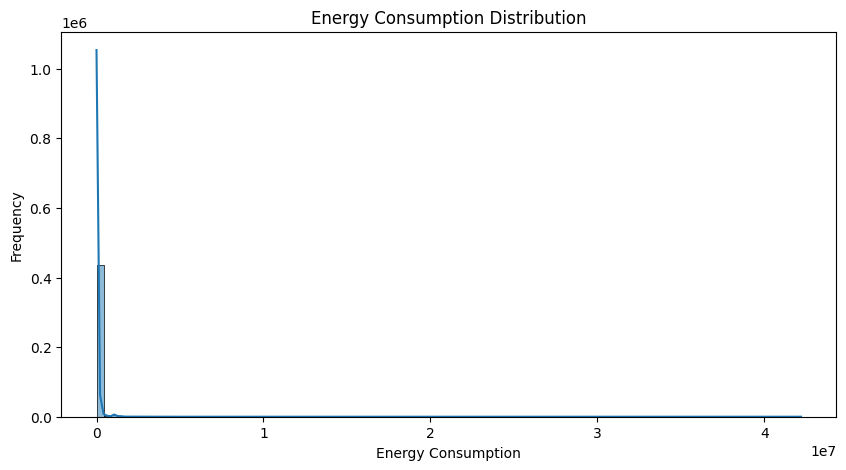

In [29]:
plt.figure(figsize=(10,5))

sns.histplot(
    data['Value'],
    bins=100,
    kde=True
)

plt.title("Energy Consumption Distribution")

plt.xlabel("Energy Consumption")

plt.ylabel("Frequency")

plt.show()

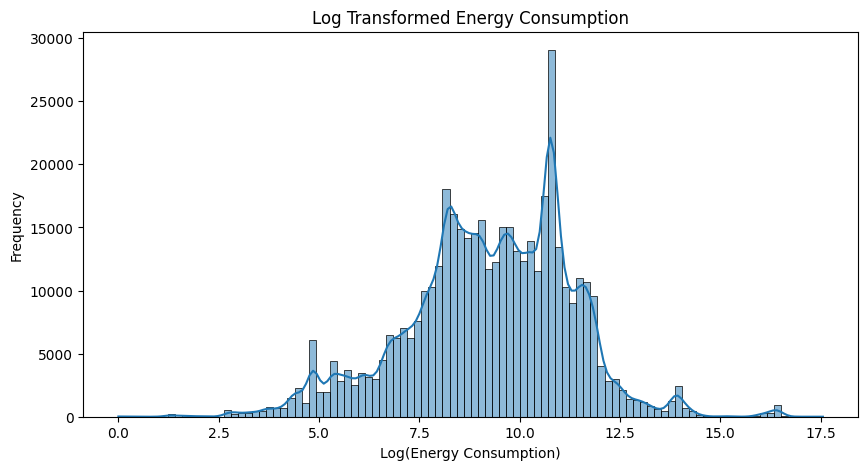

In [30]:
plt.figure(figsize=(10,5))

sns.histplot(
    data['LogValue'],
    bins=100,
    kde=True
)

plt.title("Log Transformed Energy Consumption")

plt.xlabel("Log(Energy Consumption)")

plt.ylabel("Frequency")

plt.show()

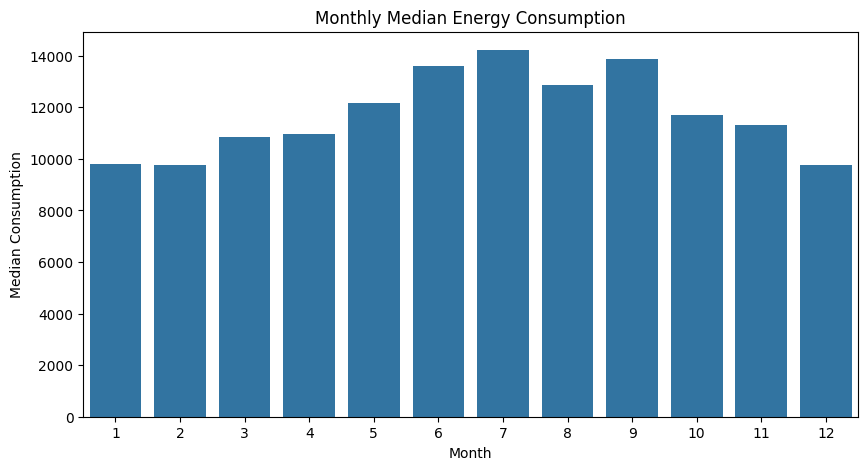

In [31]:
monthly = (
    data.groupby('Month')['Value']
    .median()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=monthly,
    x='Month',
    y='Value'
)

plt.title(
    'Monthly Median Energy Consumption'
)

plt.xlabel('Month')

plt.ylabel('Median Consumption')

plt.savefig(
    'Monthly_Median_Energy_Consumption.png',
    bbox_inches='tight'
)

plt.show()

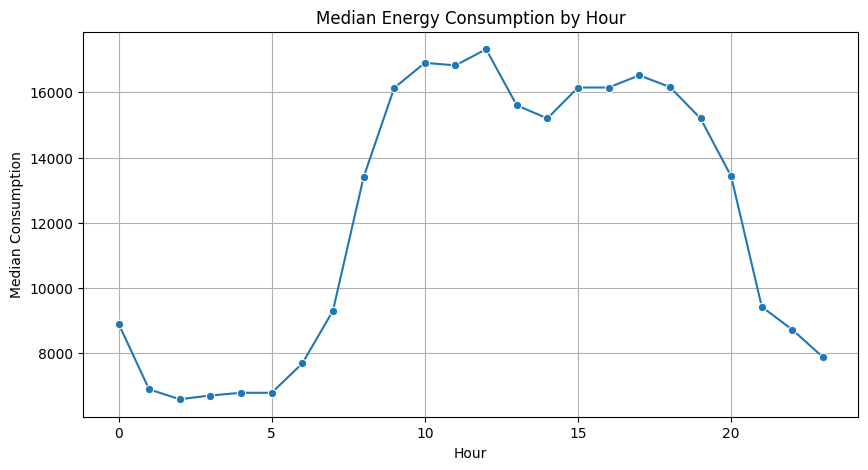

In [32]:
hourly = (
    data.groupby('Hour')['Value']
    .median()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.lineplot(
    data=hourly,
    x='Hour',
    y='Value',
    marker='o'
)

plt.title(
    'Median Energy Consumption by Hour'
)

plt.xlabel('Hour')

plt.ylabel('Median Consumption')

plt.grid(True)

plt.savefig(
    'Median Energy Consumption by Hour.png',
    bbox_inches='tight'
)

plt.show()

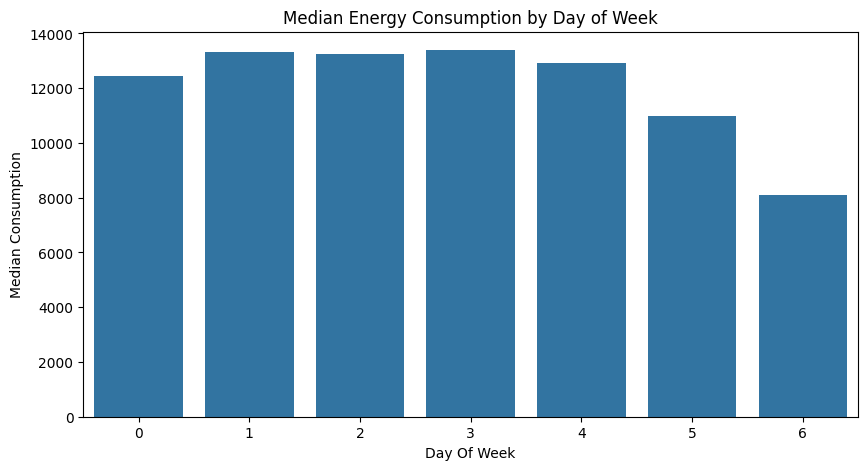

In [33]:
weekday = (
    data.groupby('DayOfWeek')['Value']
    .median()
    .reset_index()
)

plt.figure(figsize=(10,5))

sns.barplot(
    data=weekday,
    x='DayOfWeek',
    y='Value'
)

plt.title(
    'Median Energy Consumption by Day of Week'
)

plt.xlabel('Day Of Week')

plt.ylabel('Median Consumption')

plt.savefig(
    'Median Energy Consumption by Day of Week.png',
    bbox_inches='tight'
)

plt.show()

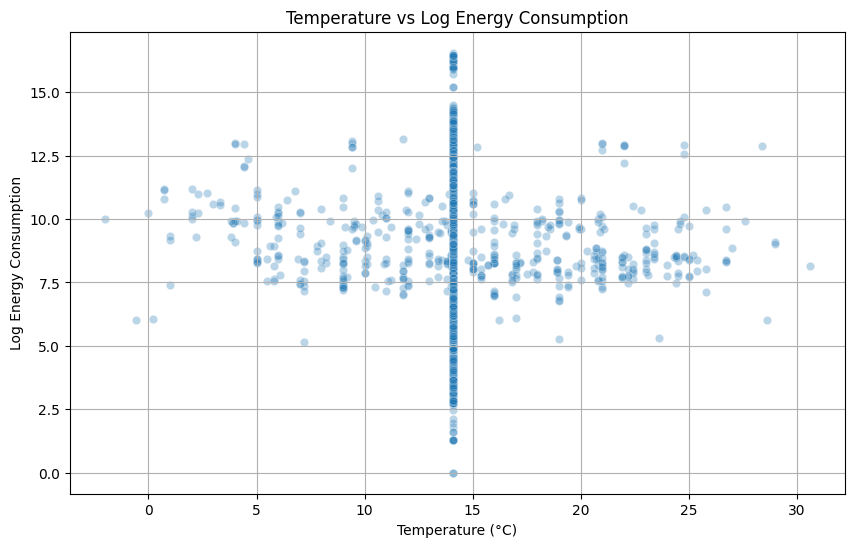

In [52]:
sample_plot = data.sample(
    min(10000, len(data)),
    random_state=42
)

plt.figure(figsize=(10,6))

sns.scatterplot(
    data=sample_plot,
    x='Temperature',
    y='LogValue',
    alpha=0.3
)

plt.title(
    'Temperature vs Log Energy Consumption'
)

plt.xlabel('Temperature (°C)')
plt.ylabel('Log Energy Consumption')

plt.grid(True)

plt.savefig(
    'Temperature vs Energy Consumption.png',
    bbox_inches='tight'
)

plt.show()

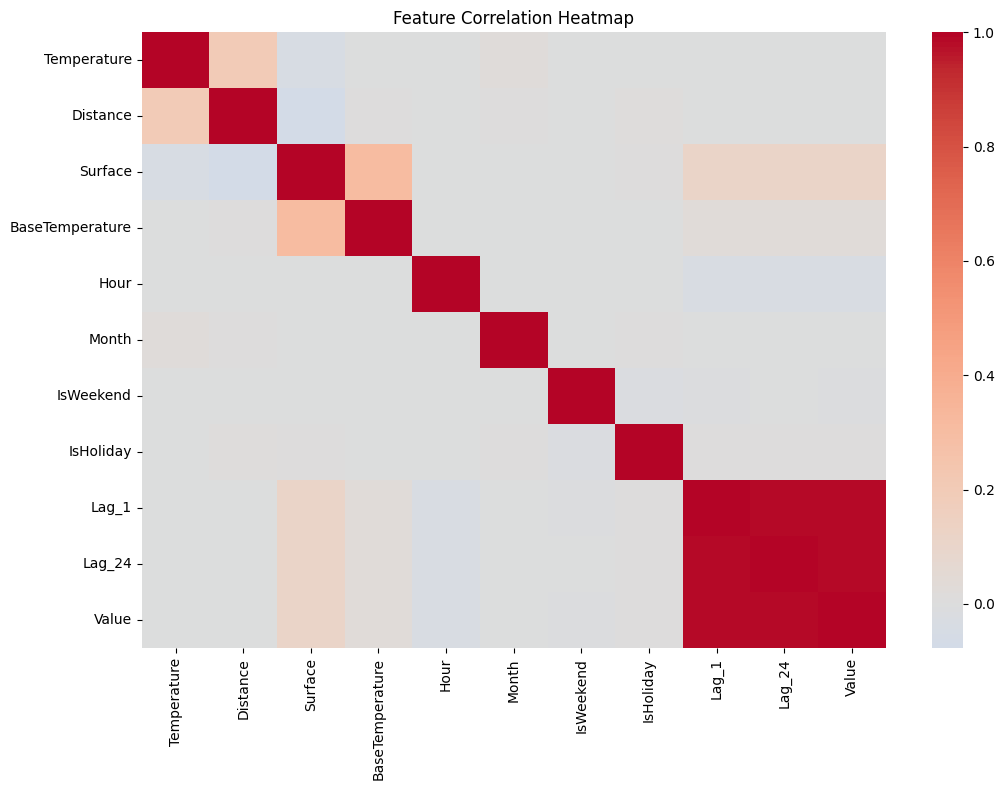

In [35]:
corr_features = [
    'Temperature',
    'Distance',
    'Surface',
    'BaseTemperature',
    'Hour',
    'Month',
    'IsWeekend',
    'IsHoliday',
    'Lag_1',
    'Lag_24',
    'Value'
]
plt.figure(figsize=(12,8))

sns.heatmap(
    data[corr_features].corr(),
    cmap='coolwarm',
    center=0
)

plt.title(
    'Feature Correlation Heatmap'
)

plt.show()

In [36]:
features = [
    'Temperature',
    'Distance',
    'Surface',
    'Sampling',
    'BaseTemperature',
    'Hour',
    'DayOfWeek',
    'Month',
    'IsWeekend',
    'IsHoliday',
    'Temp_Squared',
    'Temp_Deviation',
    'Lag_1',
    'Lag_24',
    'SiteId'
]

target = 'LogValue'

In [37]:
X = data[features]
y = data[target]

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

print(X_train.shape)
print(X_test.shape)

(357049, 15)
(89263, 15)


In [39]:
from sklearn.linear_model import LinearRegression

lr = LinearRegression()

lr.fit(
    X_train,
    y_train
)

lr_pred = lr.predict(X_test)

In [40]:
from sklearn.ensemble import RandomForestRegressor

rf = RandomForestRegressor(
    n_estimators=100,
    max_depth=15,
    random_state=42,
    n_jobs=-1
)

rf.fit(
    X_train,
    y_train
)

rf_pred = rf.predict(X_test)

In [41]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=100,
    max_depth=6,
    learning_rate=0.1,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    tree_method='hist'
)

xgb.fit(
    X_train,
    y_train
)

xgb_pred = xgb.predict(X_test)

In [42]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)

results = []

models = {
    'Linear Regression': lr_pred,
    'Random Forest': rf_pred,
    'XGBoost': xgb_pred
}

for name, pred in models.items():

    results.append([
        name,

        mean_absolute_error(
            y_test,
            pred
        ),

        np.sqrt(
            mean_squared_error(
                y_test,
                pred
            )
        ),

        r2_score(
            y_test,
            pred
        )
    ])

results_df = pd.DataFrame(
    results,
    columns=[
        'Model',
        'MAE',
        'RMSE',
        'R2'
    ]
)

results_df

,Model,MAE,RMSE,R2
0,Linear Regression,0.974786,1.192238,0.188016
1,Random Forest,0.512006,0.741805,0.685658
2,XGBoost,0.510080,0.655170,0.754795


In [43]:
results_df.to_csv(
    'model_comparison.csv',
    index=False
)

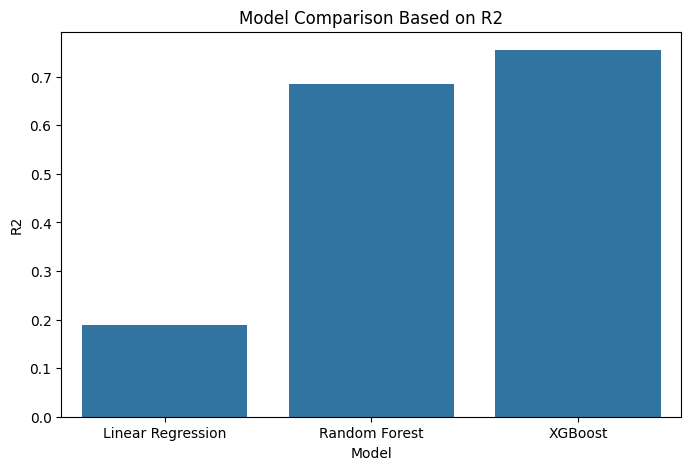

In [44]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='R2'
)

plt.title(
    'Model Comparison Based on R2'
)

plt.savefig(
    'Model Comparison Based on R2.png',
    bbox_inches='tight'
)

plt.show()

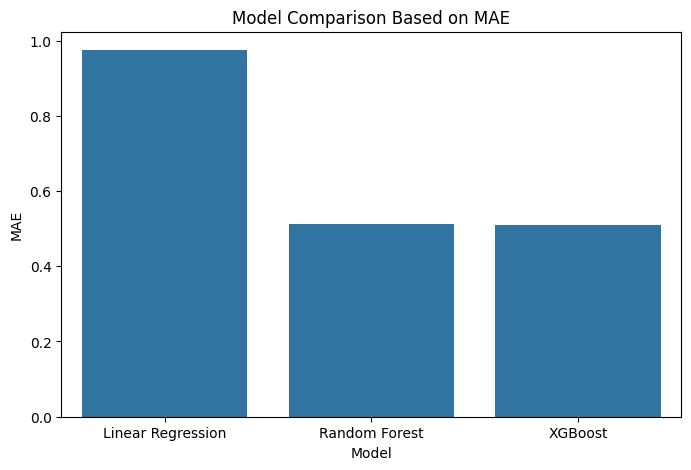

In [45]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='MAE'
)

plt.title(
    'Model Comparison Based on MAE'
)

plt.savefig(
    'Model Comparison Based on MAE.png',
    bbox_inches='tight'
)

plt.show()

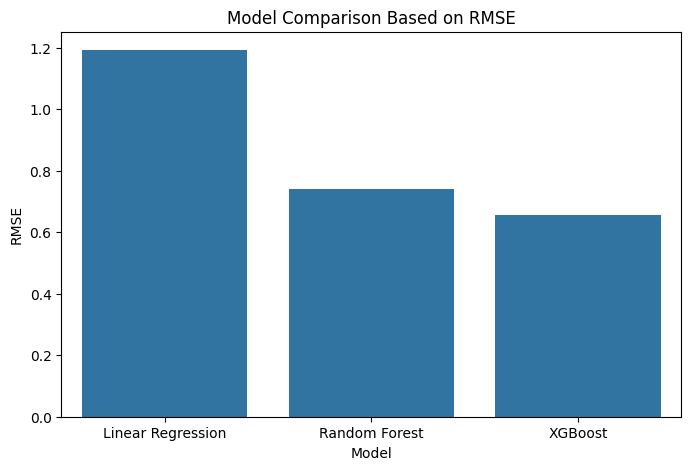

In [46]:
plt.figure(figsize=(8,5))

sns.barplot(
    data=results_df,
    x='Model',
    y='RMSE'
)

plt.title(
    'Model Comparison Based on RMSE'
)

plt.savefig(
    'Model Comparison Based on RMSE.png',
    bbox_inches='tight'
)

plt.show()

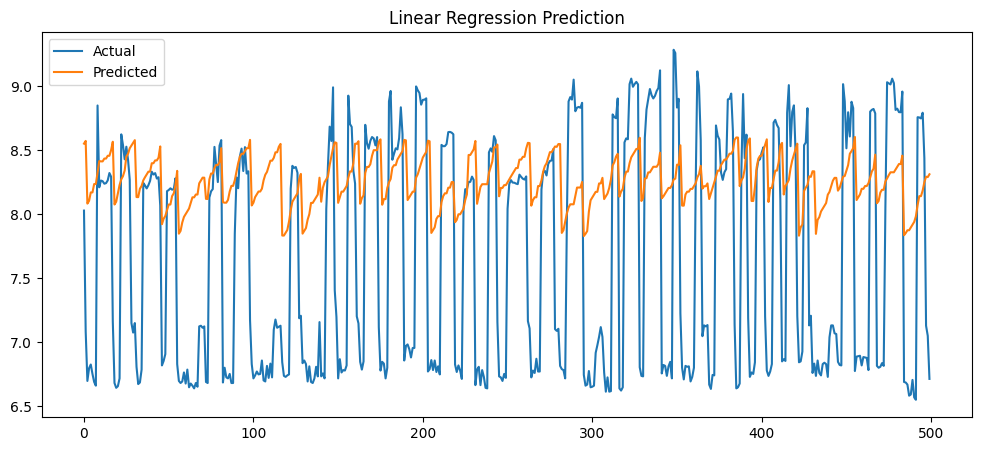

In [47]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': lr_pred
})

comparison = comparison.head(500)

plt.figure(figsize=(12,5))

plt.plot(
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title(
    'Linear Regression Prediction'
)

plt.savefig(
    'LR Comparison.png',
    bbox_inches='tight'
)

plt.show()

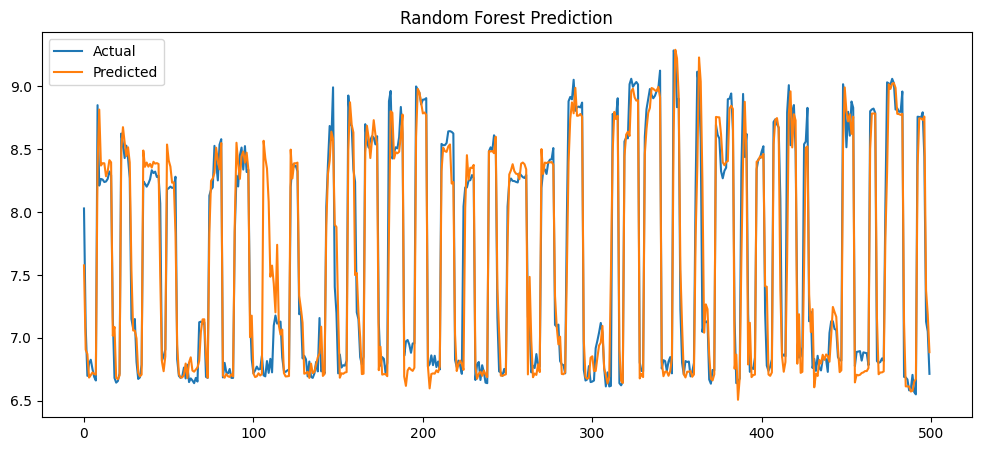

In [48]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': rf_pred
})

comparison = comparison.head(500)

plt.figure(figsize=(12,5))

plt.plot(
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title(
    'Random Forest Prediction'
)

plt.savefig(
    'RF Comparison.png',
    bbox_inches='tight'
)

plt.show()

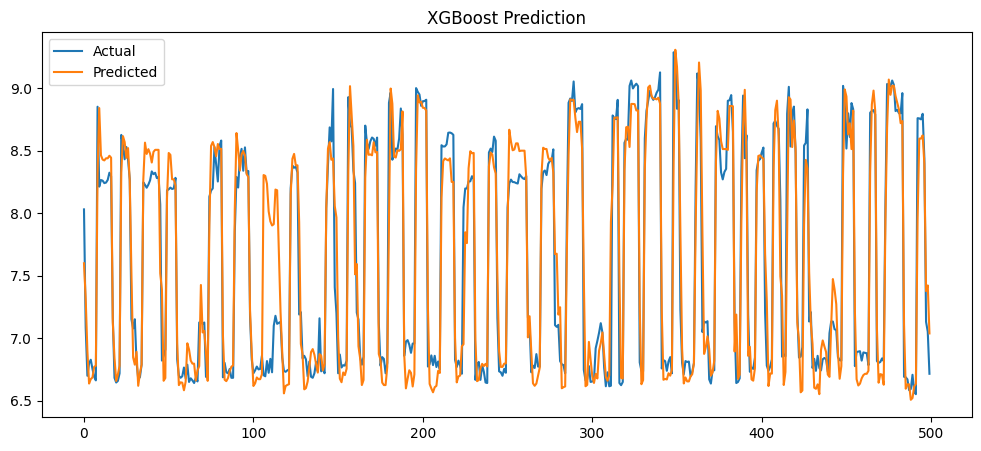

In [49]:
comparison = pd.DataFrame({
    'Actual': y_test.values,
    'Predicted': xgb_pred
})

comparison = comparison.head(500)

plt.figure(figsize=(12,5))

plt.plot(
    comparison['Actual'],
    label='Actual'
)

plt.plot(
    comparison['Predicted'],
    label='Predicted'
)

plt.legend()

plt.title(
    'XGBoost Prediction'
)

plt.savefig(
    'XGB Comparison.png',
    bbox_inches='tight'
)

plt.show()

In [50]:
importance = pd.DataFrame({
    'Feature': features,
    'Importance': rf.feature_importances_
})

importance = importance.sort_values(
    by='Importance',
    ascending=False
)

importance

,Feature,Importance
12,Lag_1,0.845826
13,Lag_24,0.047865
5,Hour,0.035628
2,Surface,0.026252
14,SiteId,0.026203
6,DayOfWeek,0.007032
7,Month,0.005863
3,Sampling,0.003006
8,IsWeekend,0.001169
9,IsHoliday,0.000761


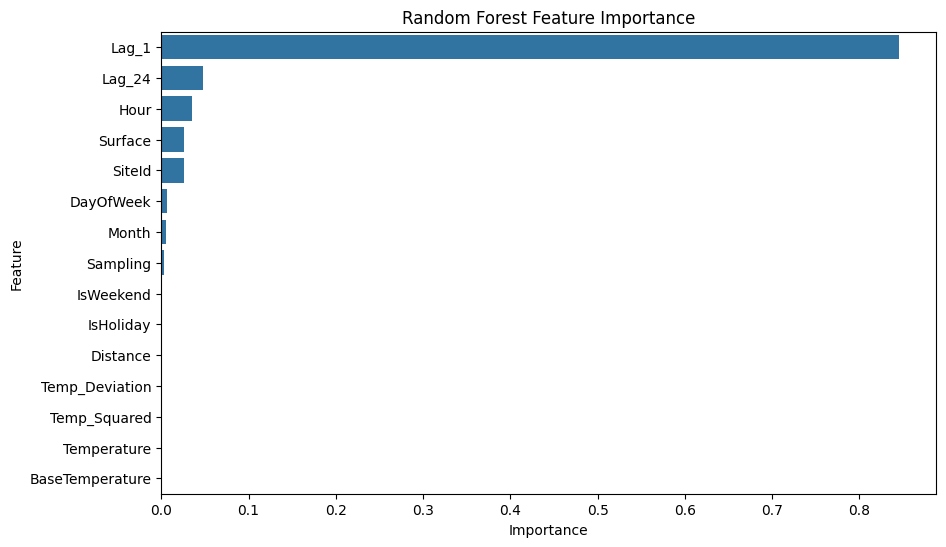

In [51]:
plt.figure(figsize=(10,6))

sns.barplot(
    data=importance,
    x='Importance',
    y='Feature'
)

plt.title(
    'Random Forest Feature Importance'
)

plt.savefig(
    'Feature Importance.png',
    bbox_inches='tight'
)

plt.show()